# Dispersion diagram: passbands of a multicell cavity

A cavity with *N* coupled cells does not have one mode per band — it has *N*, one for each **per-cell phase advance** from the 0-mode to the $\pi$-mode. Plotting frequency against phase advance gives the **Brillouin (dispersion) diagram**: each polarisation forms a passband, and the accelerating $\pi$-mode sits at the top of the fundamental monopole band.

`cav.plot_dispersion()` builds this from a solved eigenmode run — overlaying every computed polarisation, grouping modes into passbands, and (for the monopole) drawing the folded speed-of-light line the accelerating mode sits on.

In [1]:
import matplotlib.pyplot as plt
from cavsim2d import Study, EllipticalCavity
from cavsim2d.utils.style import apply_style
apply_style()

## 1. A 9-cell TESLA cavity

Nine coupled cells → nine modes per passband. We build it inside a `Study` and keep beampipes on both ends.

In [2]:
midcell   = [42, 42, 12, 19, 35, 57.652, 103.3536]   # A, B, a, b, Ri, L, Req
endcell_l = [40.34, 40.34, 10, 13.5, 39, 55.7251, 103.3536]
endcell_r = [42, 42, 9, 12.8, 39, 56.8407, 103.3536]
cavs = Study('dispersion_demo')
cav = EllipticalCavity(9, midcell, endcell_l, endcell_r, beampipe='both', name='tesla')
cavs.add_cavity([cav], ['TESLA'])

## 2. Solve the monopole and dipole passbands

We ask for both the **monopole** (accelerating) and **dipole** (deflecting, HOM) polarisations, and enough modes to fill each fundamental passband (9 cells → 9 modes, plus a couple into the next band).

In [3]:
cavs.run_eigenmode({
    'n_cells': 9,
    'polarisation': ['monopole', 'dipole'],
    'n_modes': 12,
    'boundary_conditions': 'mm',
})

## 3. The dispersion diagram

By default every solved polarisation is overlaid, coloured by polarisation, with the monopole's folded light line. The accelerating $\pi$-mode is the highest point of the fundamental monopole band, ~on the light line.

<Axes: >

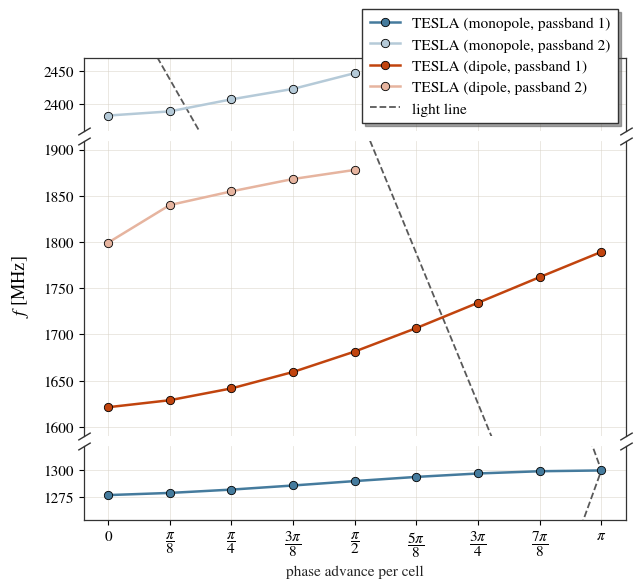

In [4]:
cav.plot_dispersion()

## 4. Just the accelerating passband

Select a single polarisation and passband. `bands` is 1-based; passband 1 is the fundamental.

In [5]:
cav.plot_dispersion(pol='monopole', bands=[1])

<Axes: xlabel='phase advance per cell', ylabel='$f$ [MHz]'>

## 5. The spectrum as a comb

The same modes as a spectral comb — vertical lines at each eigenfrequency, coloured by polarisation, with a marker at each passband's cluster mean.

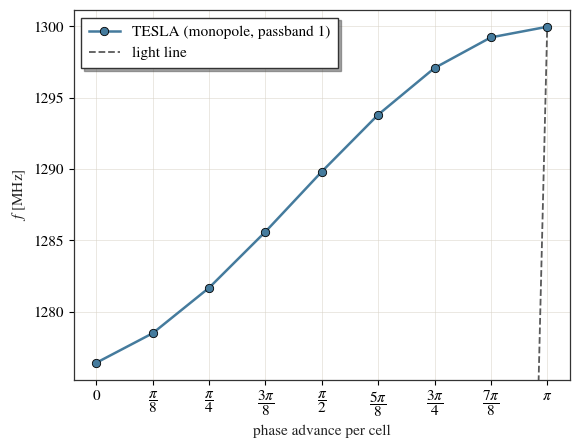

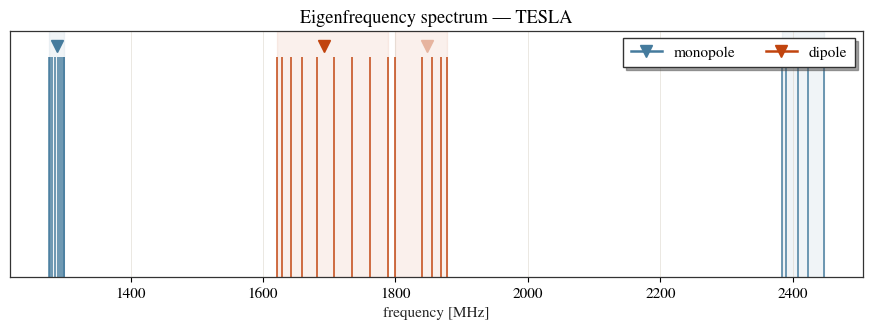

<Axes: title={'center': 'Eigenfrequency spectrum — TESLA'}, xlabel='frequency [MHz]'>

In [6]:
cav.eigenmode.plot_spectrum(bands=True)

## Where to go next

- [The TESLA elliptical cavity](elliptical_tesla.ipynb) — fundamental mode, QOIs and impedance.
- [Multicell UQ and sensitivity analysis](multicell_uq_sa.ipynb) — how the passband spreads under fabrication uncertainty.
- `cav.eigenmode.impedance()` reconstructs the beam-coupling impedance from these same modes.